In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split as tts
from sklearn import feature_selection
import SaveMol_GetDescriptors as smg
import pandas as pd
import numpy as np
import utils
import random
import xgboost as xgb
import pickle
import graph

In [2]:
d_train0 = pd.read_excel("train_data/train_fingerprint_class_new.xlsx")
d_train0

,num,smiles,MACCS-0,MACCS-1,MACCS-2,MACCS-3,MACCS-4,MACCS-5,MACCS-6,MACCS-7,...,MACCS-161,MACCS-162,MACCS-163,MACCS-164,MACCS-165,MACCS-166,Concentration,Temperature,Time(h),class
0,0,CCCCN1C=C[N+](C)=C1,0,0,0,0,0,0,0,0,...,1,1,0,0,1,0,0.359144,30,168.0,1
1,1,CCCCN1C=C[N+](C)=C1,0,0,0,0,0,0,0,0,...,1,1,0,0,1,0,3.591438,30,168.0,0
2,2,CCCCN1C=C[N+](C)=C1,0,0,0,0,0,0,0,0,...,1,1,0,0,1,0,8.978595,30,168.0,0
3,3,CCCCN1C=C[N+](C)=C1C,0,0,0,0,0,0,0,0,...,1,1,0,0,1,0,0.326264,30,168.0,1
4,4,CCCCN1C=C[N+](C)=C1C,0,0,0,0,0,0,0,0,...,1,1,0,0,1,0,3.262643,30,168.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,881,CC[N+]1(CC2=CC=CC=C2)CCCC1,0,0,0,0,0,0,0,0,...,1,1,1,0,1,0,2.000000,60,432.0,0
880,882,CC1(CC[N+](C)(C)CC1)c2ccc(c3ccc(c4ccc(c5ccc(C)...,0,0,0,0,0,0,0,0,...,1,1,1,0,1,0,1.000000,80,720.0,0
881,883,CC1(CC[N+](C)(C)CC1)c2ccc(c3ccc(c4ccc(c5ccc(C)...,0,0,0,0,0,0,0,0,...,1,1,1,0,1,0,2.000000,90,360.0,0
882,884,CC1(CC[N+](CC1)(C)C)c2ccc(c3ccc(c4cccc(c5ccc(C...,0,0,0,0,0,0,0,0,...,1,1,1,0,1,0,1.000000,80,720.0,0


In [6]:
pre0 = pd.read_csv("predict_data_f/a_fingerprint.csv")
pre01 = pd.read_csv("predict_data_f/q_fingerprint.csv")
pre02 = pd.read_csv("predict_data_f/p_fingerprint0.csv")
pre03 = pd.read_csv("predict_data_f/p_fingerprint05.csv")
pre04 = pd.read_csv("predict_data_f/p_fingerprint10.csv")
pre05 = pd.read_csv("predict_data_f/p_fingerprint15.csv")
pre06 = pd.read_csv("predict_data_f/p_fingerprint20.csv")
pre07 = pd.read_csv("predict_data_f/p_fingerprint25.csv")
pre08 = pd.read_csv("predict_data_f/p_fingerprint30.csv")
pre09 = pd.read_csv("predict_data_f/p_fingerprint35.csv")
pre10 = pd.read_csv("predict_data_f/p_fingerprint40.csv")
pre11 = pd.read_csv("predict_data_f/p_fingerprint45.csv")
pre12 = pd.read_csv("predict_data_f/p_fingerprint50.csv")
pre13 = pd.read_csv("predict_data_f/p_fingerprint60.csv")
pre14 = pd.read_csv("predict_data_f/p_fingerprint70.csv")
pre15 = pd.read_csv("predict_data_f/p_fingerprint80.csv")
pre16 = pd.read_csv("predict_data_f/p_fingerprint90.csv")
pre17 = pd.read_csv("predict_data_f/p_fingerprint100.csv")
pre18 = pd.read_csv("predict_data_f/p_fingerprint105.csv")
pre19 = pd.read_csv("predict_data_f/p_fingerprint110.csv")
pre20 = pd.read_csv("predict_data_f/p_fingerprint115.csv")
pre21 = pd.read_csv("predict_data_f/p_fingerprint120.csv")
pre22 = pd.read_csv("predict_data_f/p_fingerprint125.csv")
pre23 = pd.read_csv("predict_data_f/p_fingerprint130.csv")
pre24 = pd.read_csv("predict_data_f/p_fingerprint135.csv")
pre25 = pd.read_csv("predict_data_f/p_fingerprint140.csv")
pre26 = pd.read_csv("predict_data_f/p_fingerprint145.csv")
pre27 = pd.read_csv("predict_data_f/p_fingerprint150.csv")
pre28 = pd.read_csv("predict_data_f/p_fingerprint155.csv")
pre29 = pd.read_csv("predict_data_f/p_fingerprint160.csv")
pre30 = pd.read_csv("predict_data_f/p_fingerprint165.csv")
pre31 = pd.read_csv("predict_data_f/p_fingerprint170.csv")
pre32 = pd.read_csv("predict_data_f/p_fingerprint175.csv")
pre33 = pd.read_csv("predict_data_f/P+_fingerprint0.csv")
pre34 = pd.read_csv("predict_data_f/P+_fingerprint1.csv")
pre35 = pd.read_csv("predict_data_f/nstd_predict.csv")

pre1 = pd.concat([pre0,pre01,pre02,pre03,pre04,pre05,pre06,pre07,pre08,pre09,pre10,pre11,pre12,pre13,pre14,pre15,pre16,pre17,pre18,pre19,pre20,pre21,pre22,pre23,pre24,pre25,pre26,pre27,pre28,pre29,pre30,pre31,pre32,pre33,pre34,pre35],axis = 0)

In [7]:
data_test0 = pre1.reset_index(drop = True)
data_test0

,num,smiles,MACCS-0,MACCS-1,MACCS-2,MACCS-3,MACCS-4,MACCS-5,MACCS-6,MACCS-7,...,MACCS-160,MACCS-161,MACCS-162,MACCS-163,MACCS-164,MACCS-165,MACCS-166,Concentration,Temperature,Time(h)
0,0,C[N@+]12CC[C@H](CC1)[C@@H](OC(=O)C(O)(c1ccccc1...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1,80,720
1,1,O=C(O[C@H]1C[N@+]2(CCCOc3ccccc3)CC[C@H]1CC2)C(...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1,80,720
2,2,C[C@H]1O[C@@]2(CS1)C[N@+]1(C)CC[C@H]2CC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1,80,720
3,3,OC(c1ccccc1)(c1ccccc1)[C@]12CC[N@+](CCOCc3cccc...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1,80,720
4,4,C[N@+]12CC[C@H](CC1)[C@@H](OC(=O)C(O)(c1ccccc1...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1,80,720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260035,69406,O=C(NCc1ccc(F)cc1)C1CC[NH2+]CC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1,80,720
260036,69407,C[NH+](C)CCn1c2c(c3cc(Cl)ccc31)CCCCC2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1,80,720
260037,69408,O=C(O[C@H]1C[N@+]2(CCc3ccccc3)CC[C@H]1CC2)C1(O...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1,80,720
260038,69409,C[NH2+][C@H]1[C@H](O)C[C@@H]2[C@H]3CCc4cc(O)cc...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1,80,720


In [23]:
scaler1 = StandardScaler()
x = d_train0.iloc[:,2:-1]
x_standard=pd.DataFrame(scaler1.fit_transform(x))
x_standard.columns = x.columns
x_standard

,MACCS-0,MACCS-1,MACCS-2,MACCS-3,MACCS-4,MACCS-5,MACCS-6,MACCS-7,MACCS-8,MACCS-9,...,MACCS-160,MACCS-161,MACCS-162,MACCS-163,MACCS-164,MACCS-165,MACCS-166,Concentration,Temperature,Time(h)
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,-1.557677,-0.306691,0.324037,0.0,-1.024348,-2.792176,-0.154244
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,-1.557677,-0.306691,0.324037,0.0,0.698211,-2.792176,-0.154244
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,-1.557677,-0.306691,0.324037,0.0,3.569143,-2.792176,-0.154244
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,-1.557677,-0.306691,0.324037,0.0,-1.041870,-2.792176,-0.154244
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,-1.557677,-0.306691,0.324037,0.0,0.522989,-2.792176,-0.154244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,0.641982,-0.306691,0.324037,0.0,-0.149900,-1.051537,-0.108249
880,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,0.641982,-0.306691,0.324037,0.0,-0.682822,0.108888,-0.058072
881,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,0.641982,-0.306691,0.324037,0.0,-0.149900,0.689101,-0.120793
882,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,0.641982,-0.306691,0.324037,0.0,-0.682822,0.108888,-0.058072


In [9]:
y = pre1.iloc[:,2:]
y_standard=pd.DataFrame(scaler1.transform(y))
y_standard.columns = y.columns
y_standard

,MACCS-0,MACCS-1,MACCS-2,MACCS-3,MACCS-4,MACCS-5,MACCS-6,MACCS-7,MACCS-8,MACCS-9,...,MACCS-160,MACCS-161,MACCS-162,MACCS-163,MACCS-164,MACCS-165,MACCS-166,Concentration,Temperature,Time(h)
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,0.641982,3.260610,0.324037,0.0,-0.682822,0.108888,-0.058072
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-2.487366,0.2177,0.691564,0.641982,3.260610,0.324037,0.0,-0.682822,0.108888,-0.058072
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,-1.445998,0.641982,3.260610,0.324037,0.0,-0.682822,0.108888,-0.058072
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-2.487366,0.2177,0.691564,0.641982,3.260610,0.324037,0.0,-0.682822,0.108888,-0.058072
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,0.641982,3.260610,0.324037,0.0,-0.682822,0.108888,-0.058072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-2.487366,0.2177,0.691564,0.641982,3.260610,0.324037,0.0,-0.682822,0.108888,-0.058072
260036,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,0.641982,-0.306691,0.324037,0.0,-0.682822,0.108888,-0.058072
260037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-2.487366,0.2177,0.691564,0.641982,3.260610,0.324037,0.0,-0.682822,0.108888,-0.058072
260038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.402032,0.2177,0.691564,0.641982,3.260610,0.324037,0.0,-0.682822,0.108888,-0.058072


In [10]:
# ----------------------------------------------------------model-------------------------

In [25]:
xtrain,xtest,ytrain,ytest=tts(x_standard,d_train0.iloc[:,-1],test_size=0.15,random_state=0)

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:55:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)
E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:55:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


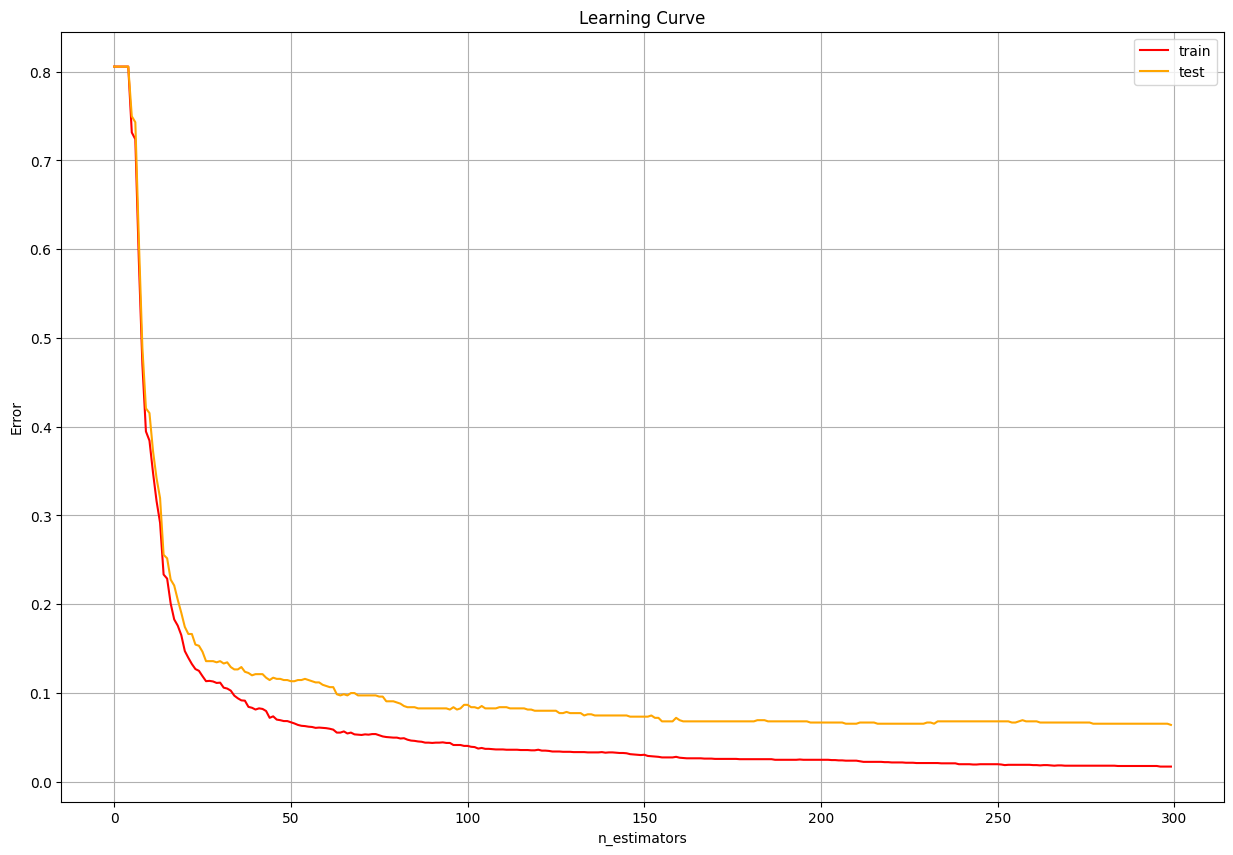

In [12]:
dtrain=xgb.DMatrix(xtrain,ytrain)
param0={'silent':True
        ,'obj':'binary:logistic'
        ,'eval_metric': 'error'
        ,'subsample':1
        ,'max_depth':4
        ,'eta':0.05
        ,'gamma':0
        ,'lambda':0.5
        ,'alpha':0
        ,'colsample_bytree':1
        ,'colsample_bylevel':1
        ,'colsample_bynode':1
        ,'scale_pos_weight':8
        ,'random_state':0}
n_estimators=300
curve0=xgb.cv(param0,dtrain,n_estimators,5)
fig,ax=plt.subplots(1,figsize=(15,10))
ax.grid()
ax.plot(range(num_round),curve0.iloc[:,0],c="red",label="train")
ax.plot(range(num_round),curve0.iloc[:,2],c="orange",label="test")
ax.legend()
plt.xlabel('n_estimators')
plt.ylabel('Error')
plt.title('Learning Curve')
plt.show()

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:55:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


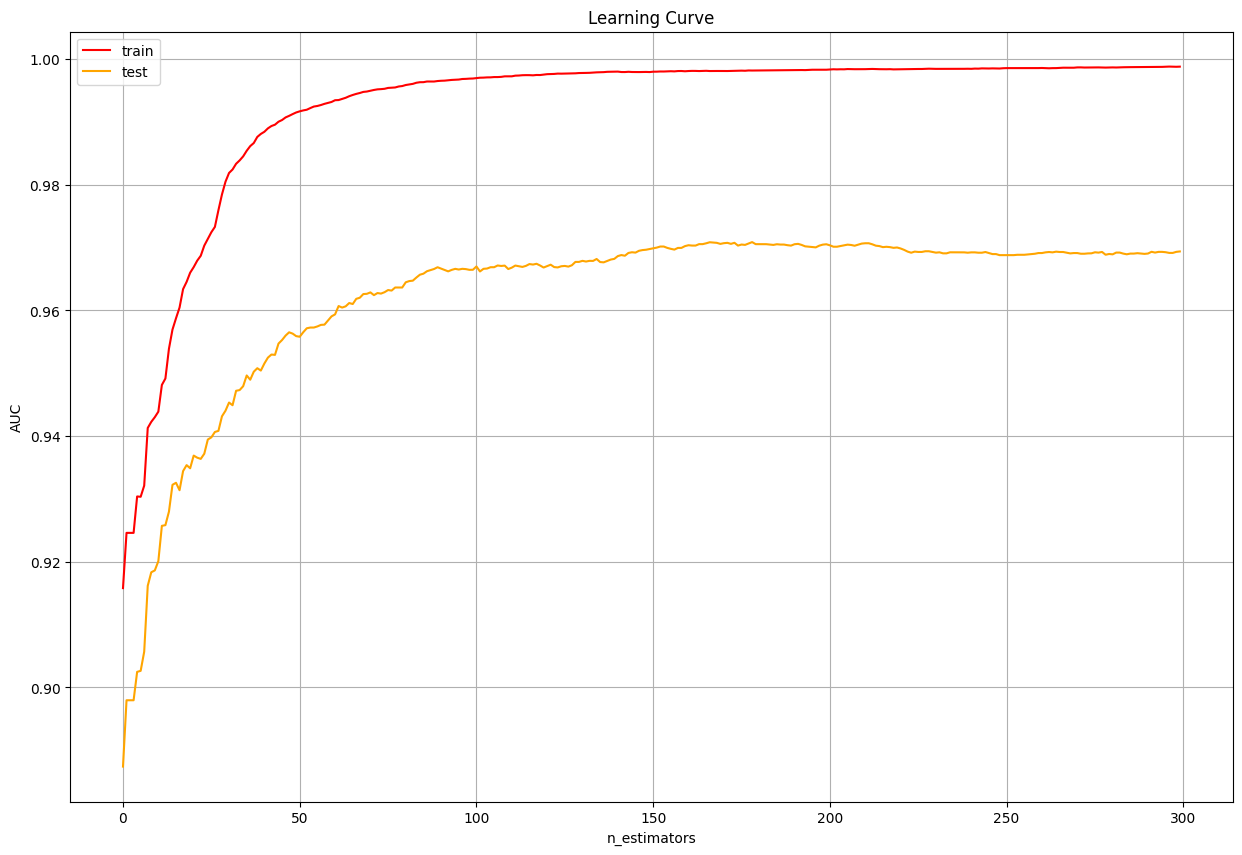

In [13]:
dtrain=xgb.DMatrix(xtrain,ytrain)
param0={'silent':True
        ,'obj':'binary:logistic'
        ,'eval_metric': 'auc'
        ,'subsample':1
        ,'max_depth':4
        ,'eta':0.05
        ,'gamma':0
        ,'lambda':0.5
        ,'alpha':0
        ,'colsample_bytree':1
        ,'colsample_bylevel':1
        ,'colsample_bynode':1
        ,'scale_pos_weight':8
        ,'random_state':0}
n_estimators=300
curve0=xgb.cv(param0,dtrain,n_estimators,5)
fig,ax=plt.subplots(1,figsize=(15,10))
ax.grid()
ax.plot(range(num_round),curve0.iloc[:,0],c="red",label="train")
ax.plot(range(num_round),curve0.iloc[:,2],c="orange",label="test")
ax.legend()
plt.xlabel('n_estimators')
plt.ylabel('AUC')
plt.title('Learning Curve')
plt.show()

In [27]:
dtrain=xgb.DMatrix(x_standard,d_train0.iloc[:,-1])
param0={'silent':True
            ,'obj':'binary:logistic'
            ,'eval_metric': 'auc'
            ,'subsample':1
            ,'max_depth':4
            ,'eta':0.05
            ,'gamma':0
            ,'lambda':0.5
            ,'alpha':0
            ,'colsample_bytree':1
            ,'colsample_bylevel':1
            ,'colsample_bynode':1
            ,'scale_pos_weight':8
            ,'random_state':0}
n_estimators=250
model_f=xgb.train(param0,dtrain,n_estimators)
# pickle.dump(model_f, open("XGBoost_f.dat","wb"))

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:17:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:21:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


<Figure size 700x600 with 0 Axes>

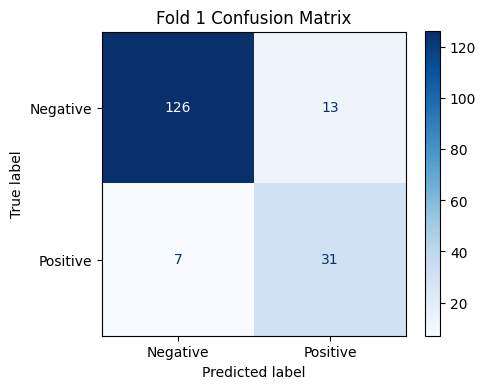

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:21:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


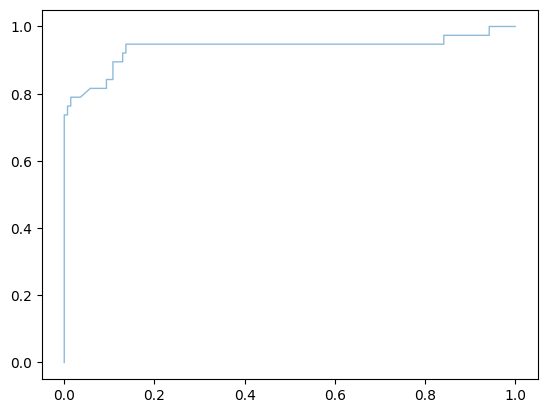

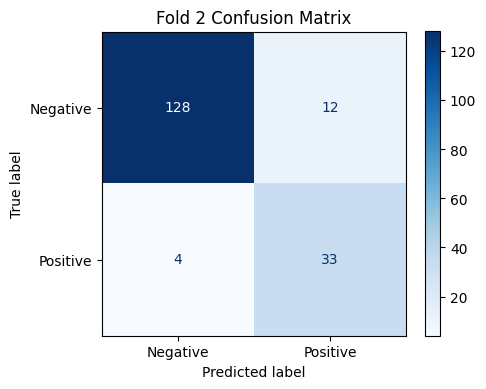

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:21:53] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


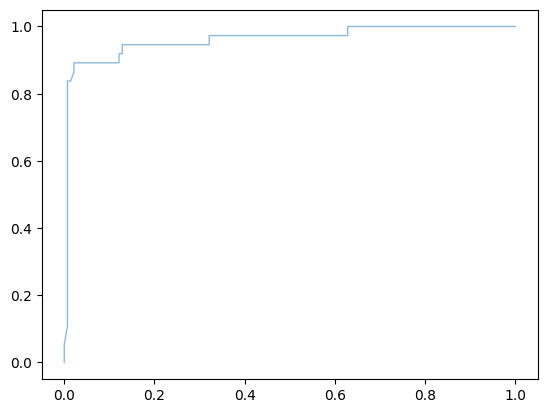

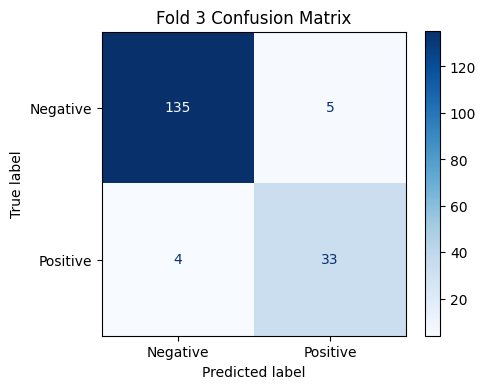

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:21:53] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


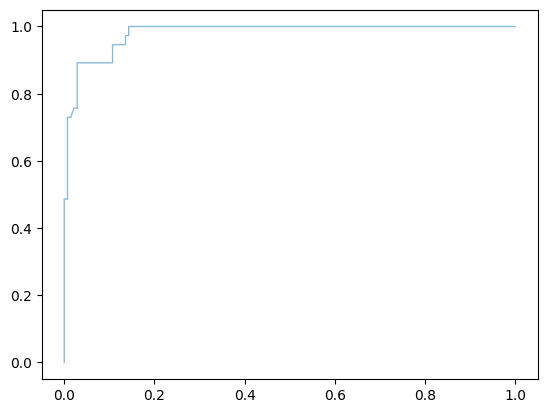

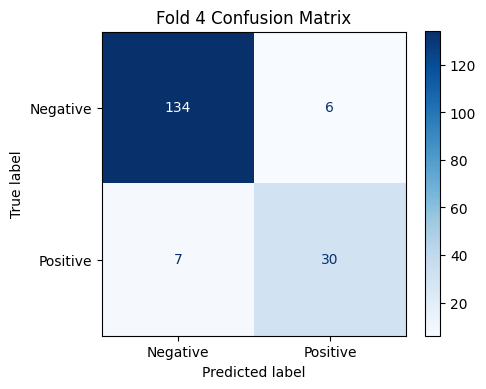

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:21:53] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


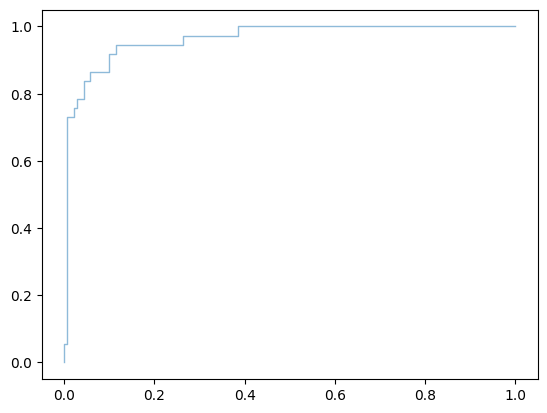

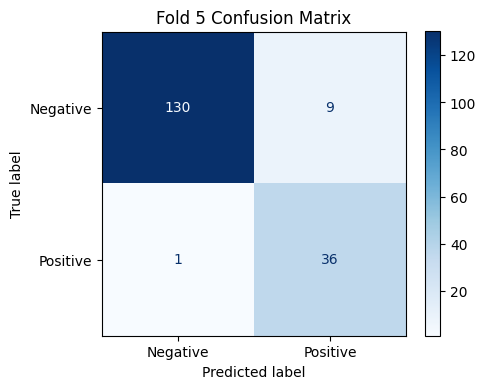

AUC       : 0.9667 ± 0.0189
Accuracy  : 0.9231 ± 0.0227


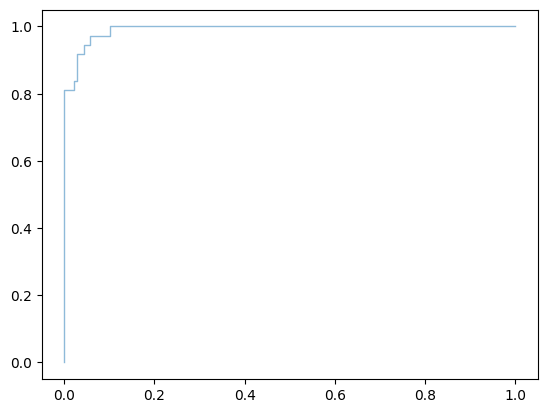

In [9]:
#-------------5 folds experiments-----------------------
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)

x_5folds = d_train0.iloc[:,2:-1]
y_5folds = d_train0.iloc[:,-1]

# 标准化
scaler_5folds = StandardScaler()
x_standard_5folds = scaler_5folds.fit_transform(x_5folds)

auc_list = []
acc_list = []
roc_data = {}

mean_fpr = np.linspace(0,1,1000)
tprs = []

plt.figure(figsize=(7,6))

for fold, (train_idx, test_idx) in enumerate(skf.split(x_standard_5folds, y_5folds)):

    X_train, X_test = x_standard_5folds[train_idx], x_standard_5folds[test_idx]
    y_train, y_test = y_5folds.iloc[train_idx], y_5folds.iloc[test_idx]

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    param0={'silent':True
            ,'obj':'binary:logistic'
            ,'eval_metric': 'auc'
            ,'subsample':1
            ,'max_depth':4
            ,'eta':0.05
            ,'gamma':0
            ,'lambda':0.5
            ,'alpha':0
            ,'colsample_bytree':1
            ,'colsample_bylevel':1
            ,'colsample_bynode':1
            ,'scale_pos_weight':8
            ,'random_state':0}

    model = xgb.train(
        param,
        dtrain,
        250
    )

    y_prob = model.predict(dtest)
    y_pred = (y_prob > 0.51).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
   
    disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive'])
    
    disp.plot(
    cmap='Blues',
    ax=ax_cm,
    values_format='d'
    )
    ax_cm.set_title(f'Fold {fold+1} Confusion Matrix')
    plt.tight_layout()
    plt.show()

    acc = accuracy_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    auc_list.append(roc_auc)
    acc_list.append(acc)

    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    plt.plot(
        fpr,
        tpr,
        lw=1,
        alpha=0.5,
        label=f'Fold {fold+1} AUC={roc_auc:.3f}'
    )
    
    roc_data[f'Fold_{fold+1}'] = pd.DataFrame({
    'FPR': fpr,
    'TPR': tpr 
})
print(f"AUC       : {np.mean(auc_list):.4f} ± {np.std(auc_list):.4f}")
print(f"Accuracy  : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")

# output_file = 'Fingerprint_5fold_ROC_data.xlsx'

# with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
#     for sheet_name, df in roc_data.items():
#         df.to_excel(writer, sheet_name=sheet_name, index=False)
# print("Already Saved")

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:20:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


<Figure size 700x600 with 0 Axes>

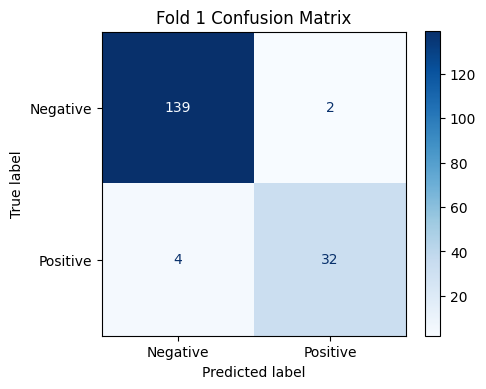

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:20:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


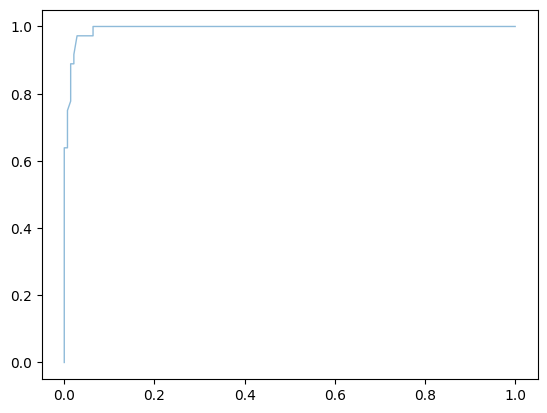

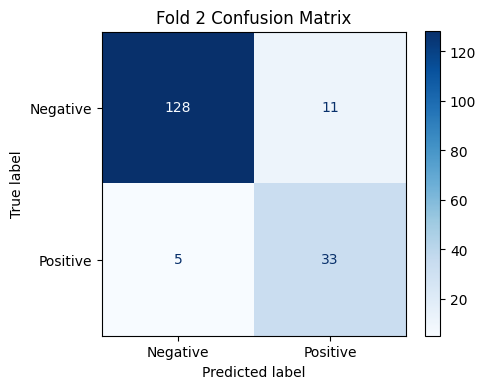

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:20:57] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


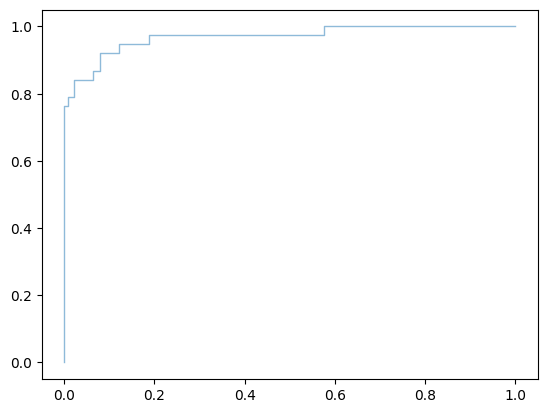

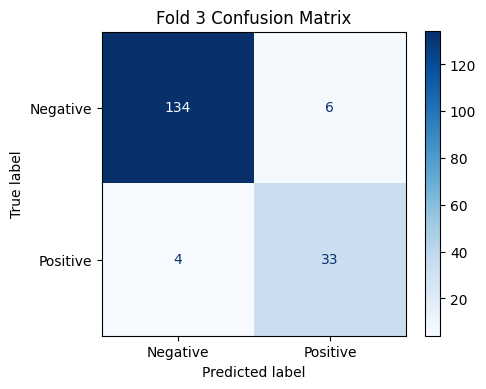

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:20:57] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


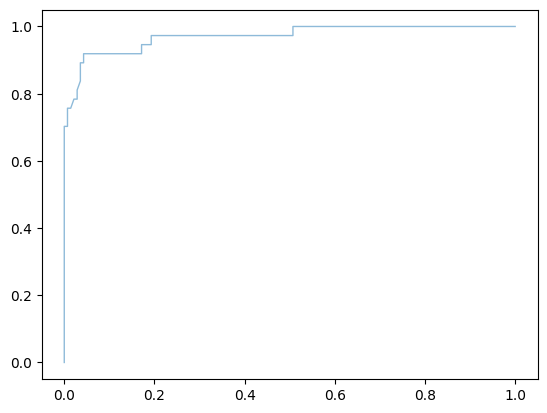

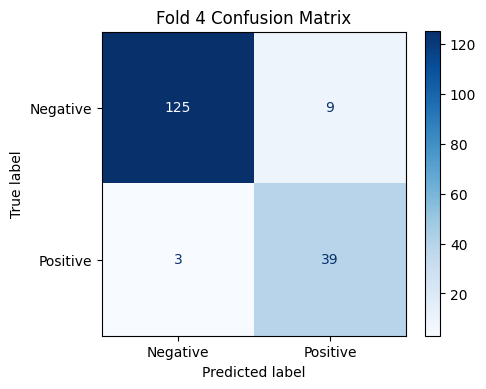

E:\python\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:20:57] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "obj", "silent" } are not used.

  warnings.warn(smsg, UserWarning)


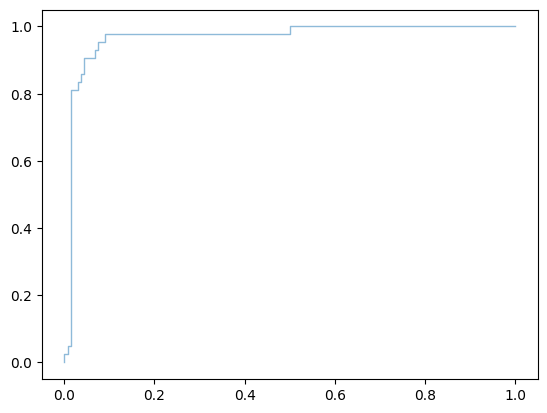

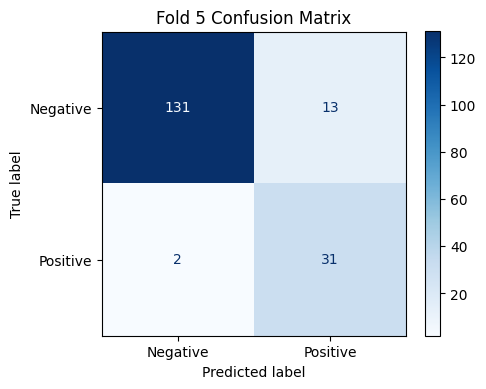

ROC-AUC           : 0.9771 ± 0.0102
Accuracy          : 0.9333 ± 0.0203
Already Saved


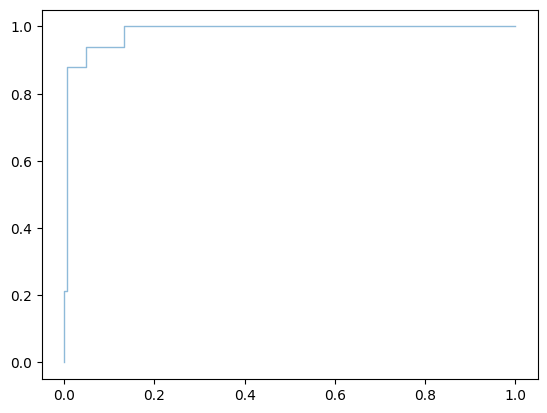

In [7]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_curve,
    auc,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

x_group_5folds = d_train0.iloc[:,2:-1]
y_group_5folds = d_train0.iloc[:,-1]

groups = d_train0.iloc[:,0]

scaler = StandardScaler()
x_standard_group_5folds = scaler.fit_transform(x_group_5folds)

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)

auc_list2 = []
acc_list2 = []
roc_data2 = {}

mean_fpr = np.linspace(0,1,1000)
tprs = []

plt.figure(figsize=(7,6))

for fold, (train_idx, test_idx) in enumerate(
    sgkf.split(x_standard_group_5folds, y_group_5folds, groups)
):

    X_train = x_standard_group_5folds[train_idx]
    X_test = x_standard_group_5folds[test_idx]

    y_train = y_group_5folds.iloc[train_idx]
    y_test = y_group_5folds.iloc[test_idx]

    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    param={'silent':True
            ,'obj':'binary:logistic'
            ,'eval_metric': 'auc'
            ,'subsample':1
            ,'max_depth':4
            ,'eta':0.05
            ,'gamma':0
            ,'lambda':0.5
            ,'alpha':0
            ,'colsample_bytree':1
            ,'colsample_bylevel':1
            ,'colsample_bynode':1
            ,'scale_pos_weight':8
            ,'random_state':0}

    model = xgb.train(
        param,
        dtrain,
        num_boost_round=250
    )

    y_prob = model.predict(dtest)
    y_pred = (y_prob > 0.51).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
   
    disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive'])
    
    disp.plot(
    cmap='Blues',
    ax=ax_cm,
    values_format='d'
    )
    ax_cm.set_title(f'Fold {fold+1} Confusion Matrix')
    plt.tight_layout()
    plt.show()
    
    acc = accuracy_score(y_test, y_pred)
    acc_list2.append(acc)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    auc_list2.append(roc_auc)

    interp_tpr = np.interp(
        mean_fpr,
        fpr,
        tpr
    )

    interp_tpr[0] = 0.0

    tprs.append(interp_tpr)

    plt.plot(
        fpr,
        tpr,
        lw=1,
        alpha=0.5,
        label=f'Fold {fold+1} AUC={roc_auc:.3f}'
    )
    
    roc_data2[f'Fold_{fold+1}'] = pd.DataFrame({
    'FPR': fpr,
    'TPR': tpr })

mean_tpr = np.mean(tprs, axis=0)

mean_tpr[-1] = 1.0

mean_auc = auc(mean_fpr, mean_tpr)

std_auc = np.std(auc_list2)

print(f"ROC-AUC           : {np.mean(auc_list2):.4f} ± {np.std(auc_list2):.4f}")
print(f"Accuracy          : {np.mean(acc_list2):.4f} ± {np.std(acc_list2):.4f}")

output_file2 = 'Fingerprint_group_5fold_ROC_data.xlsx'

with pd.ExcelWriter(output_file2, engine='openpyxl') as writer:
    for sheet_name, df in roc_data2.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)
print("Already Saved")

In [29]:
dtest = xgb.DMatrix(x_standard)
pred=model_f.predict(dtest)
pre = pd.DataFrame(pred)

when tpr-fpr is max, the threshold is 0.54757124
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.00143266 0.00143266 0.00143266
 0.00143266 0.00143266 0.00143266 0.00143266 0.00143266 0.00143266
 0.00143266 0.00143266 0.00143266 0.00143266 0.00143266 0.00573066
 0.00573066 0.00859599 0.01002865 0.01146132 0.01146132 0.01289398
 0.01575931 0.02292264 0.02292264 0.02578797 0.0286533  0.0286533
 0.03581662 0.04154728 0.04441261 0.04584527 0.0487106  0.06303725
 0.06590258 0.06876791 0.07163324 0.0730659  0.07593123 0.08166189
 0.08595989 0.09025788 0.09312321 0.09598854 0.10315186 0.10601719
 0.10888252 0.11031519 0.11461318 0.12464183 0.12750716 0.13037249
 0.13323782 0.13467049 0.14183381 0.16189112 0.16475645 0.17048711
 0.17335244 0.17621777 0.17908309 0.18338109 0.18624642 0.18767908
 0.19054441 0.19627507 0.1991404  0.20200573 0.20630372 0.20916905
 0.22206304 0.22492837 0.23209

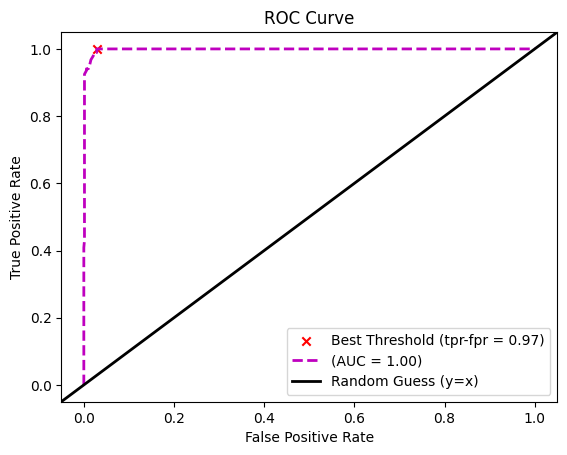

In [52]:
graph.ROC_curve(d_train0.iloc[:,-1],pred,1,True,"\\roc_descriptor_f.xlsx")

Best Threshold:  0.70674664
Best F1-score:  0.9589041095890412
[1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.     

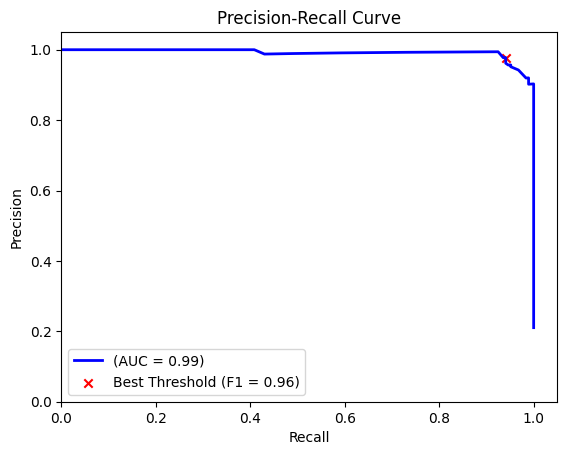

In [55]:
graph.PR_curve(d_train0.iloc[:,-1],pred,1,True,"\\pr_descriptor_f.xlsx")

In [58]:
ypred = pred.copy()
ypred[pred >0.51]=1
ypred[ypred!=1]=0

<Axes: title={'center': 'Confusion matrix (without normalization)'}, xlabel='Predicted label', ylabel='True label'>

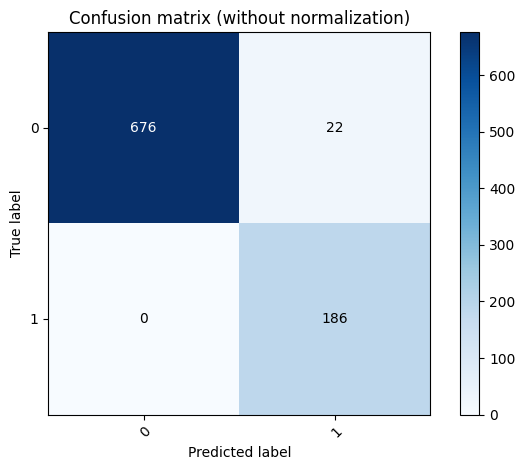

In [61]:
graph.plot_confusion_matrix(d_train0.iloc[:,-1],ypred,np.array(["0","1"]))

In [43]:
from sklearn.metrics import matthews_corrcoef, balanced_accuracy_score, precision_recall_curve, roc_curve, auc

y_true = d_train0.iloc[:, -1]

y_pred = (pred > 0.51).astype(int)

y_pred = np.array(y_pred).flatten()

mcc = matthews_corrcoef(y_true, y_pred)

bacc = balanced_accuracy_score(y_true, y_pred)

precision, recall, _ = precision_recall_curve(y_true, y_pred)
pr_auc = auc(recall, precision)

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

print(f"MCC: {mcc:.4f}")
print(f"Balanced Accuracy: {bacc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

MCC: 0.9306
Balanced Accuracy: 0.9842
PR-AUC: 0.9471
ROC-AUC: 0.9842


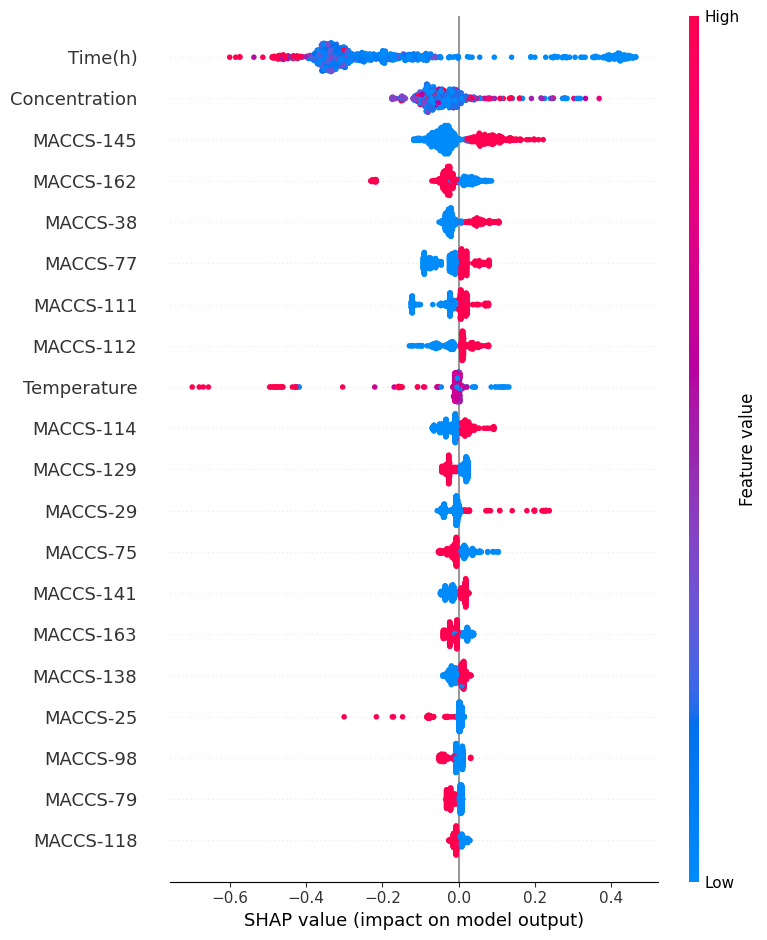

In [64]:
import shap

explainer = shap.TreeExplainer(model_f)
shap_values = explainer.shap_values(x_standard)
plt.figure()
shap.summary_plot(shap_values,x_standard)
# plt.savefig(r'C:\Users\hp\Desktop\AEM_project\output_graph\xgb_d_shap.png', format='png',dpi = 1000)

In [67]:
df_all = []
for i in range(x_standard.shape[1]):
    df_i = pd.DataFrame({
        "SHAP Value": shap_values[:, i],
        "Feature Value": x_standard.iloc[:, i],
        "Feature Name": [f"Feature_{i}"] * x_standard.shape[0]
    })
    df_all.append(df_i)

df_total = pd.concat(df_all, ignore_index=True)
# df_total.to_excel("shap_all_features_d.xlsx", index=False)

In [21]:
dtest = xgb.DMatrix(y_standard)
y_pred = model_f.predict(dtest)
y_pred = pd.DataFrame(y_pred)
y_pred.columns = ['level']

ypred0 = y_pred.copy()
ypred0[y_pred >0.51]=1
ypred0[ypred0!=1]=0
ypred1 = pd.DataFrame(ypred0)
ypred1.columns = ['predict_class']

output = pd.concat([data_test0.iloc[:,:2],ypred1, y_pred], axis=1)
output.to_excel('output_f_all.xlsx', index=False)

In [78]:
k = []
for i in range(len(output.index)):
    if output.iloc[i,2]==1:
        k.append(i)
output0 = output.iloc[k,:]
output0.reset_index(inplace=True, drop=True)

In [83]:
from rdkit import rdBase
rdBase.DisableLog('rdApp.warning')
from rdkit import Chem
from rdkit.Contrib.SA_Score import sascorer
SMILES=output0['smiles']
SA=[]
for n,i in enumerate(SMILES):
       x_mol=Chem.MolFromSmiles(i)  
       SAscore=sascorer.calculateScore(x_mol)
       SA.append(SAscore)

output_final=pd.concat([output0,pd.DataFrame(SA,columns=['SA'])],axis=1)

num = len(output0.index)

ll = []
for ii in range(num):
    i = output0.iloc[ii,1]
    if '#'  in i or 'Si' in i or 'Br'  in i or 'Cl' in i or 'I'  in i or 'C(=O)O' in i or 'B' in i:
        ll.append(ii)
output_final.drop(index=ll, inplace=True, axis=0)
output_final.reset_index(inplace=True, drop=True)

print(output_final)
output_final.to_excel('output_f.xlsx', index=False)

        num                                             smiles  predict_class  \
0      5601           FC(F)(F)[P+](N1CCCCC1)(N1CCCCC1)N1CCCCC1            1.0   
1      6941   CC[NH+](CC)C1CCN(c2ccc(C(=O)C(F)(F)F)c[nH+]2)CC1            1.0   
2      6969                  C[N+]1(P(C2CCCCC2)C2CCCCC2)CCCCC1            1.0   
3      8204               CCN(c1ncc(F)cc1[N+](C)(C)CC)C1CCNCC1            1.0   
4     12656                   FC(F)(F)c1ccc(NC2CC[NH2+]CC2)nc1            1.0   
...     ...                                                ...            ...   
2604  69125  NS(=O)(=O)c1c(S(=O)(=O)CC[NH3+])ccc(-c2c[nH]c3...            1.0   
2605  69155  COc1cccc(OCCC[NH3+])c1-c1cc(NC(=O)c2ccncc2)n[nH]1            1.0   
2606  69213                             C=Cc1[nH]cc[n+]1CCCCCC            1.0   
2607  69269  CCC(=O)CCCCC[C@H](NC(=O)Cc1ccc2occc2c1)C1=NC=C...            1.0   
2608  69344   CCCCCCCCc1c[n+](Cc2ccccc2)nn1Cc1ccc(C(C)(C)C)cc1            1.0   

         level        SA  


In [ ]:
d_p = pd.read_excel("output14.xlsx")
l_p = d_p['smiles_d'].tolist()
print(l_p)

m = 0
for i in l_p:
    to_p = smg.GetDescriptors(i, 1, 80, 720)  
    to_p_standard = pd.DataFrame(scaler1.transform(to_p))
    to_p_standard.columns = to_p.columns

    # 计算 SHAP 值
    explainer = shap.TreeExplainer(model_d)
    shap_values = explainer.shap_values(to_p_standard)

    # **四舍五入处理 SHAP 值和输入特征**
    shap_values_rounded = np.round(shap_values, 2) 
    to_p_standard_rounded = to_p_standard.round(2) 

    # 生成 force_plot
    fig = shap.force_plot(
        explainer.expected_value, 
        shap_values_rounded, 
        to_p_standard_rounded, 
        show=False, 
        matplotlib=True
    )

    # **调整坐标刻度格式**
    plt.gca().set_xticklabels([f"{tick:.2f}" for tick in plt.gca().get_xticks()])
    plt.gca().set_yticklabels([f"{tick:.2f}" for tick in plt.gca().get_yticks()])

    # 保存图片
    plt.savefig(r'C:\Users\hp\Desktop\shap\f_' + str(m) + '.png', format='png', dpi=1000)
    plt.close()  
    m += 1